# Whale Optimization Algorithm (WOA)
### Jordan Burmylo-Magrann

This notebook implements the **Whale Optimization Algorithm (WOA)** as described in the paper:

**S. Mirjalili & A. Lewis — “The Whale Optimization Algorithm”, 2016.**

Algorithm components implemented:

- Encircling prey  
- Bubble-net strategy  
- Spiral updating  
- Random exploration via |A| > 1  
- Adaptive parameter *a* decreasing from 2 → 0  

We test the algorithm on benchmark functions and plot its convergence.


In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Benchmark Function (Sphere)

We use the classic Sphere function:

\[
f(x) = \sum_{i=1}^{n} x_i^2
\]

Global optimum = 0 at x = 0.


In [7]:
def sphere(x):
    return np.sum(x**2)

## Whale Optimization Algorithm – Implementation

This implementation (see WOA.py) follows Section 2.2 of the WOA paper:

- **Encircling prey** — Eq. (2.1), (2.2)  
- **Coefficient vectors** — Eq. (2.3), (2.4)  
- **Bubble-net attack (shrinking + spiral)** — Eq. (2.5), (2.6)  
- **Search for prey (exploration)** — Eq. (2.7), (2.8)

A linearly decreasing parameter:

\[
a = 2 - \frac{2t}{T}
\]

controls exploration → exploitation.


In [1]:
from WOA import WOA

## Run WOA on the Sphere Function


In [9]:
best, curve = WOA(
    f=sphere,
    dim=30,
    lb=-100,
    ub=100,
    num_whales=30,
    max_iter=300
)

print("Best position found:", best)
print("Best fitness:", sphere(best))


Best position found: [ 1.01025019e-26 -4.65871025e-27  8.42891858e-27  9.61891219e-27
 -7.01187326e-28  2.28226801e-26  1.20314207e-26 -4.95932262e-27
  1.60069057e-26  1.13735310e-26 -1.57008376e-26  2.46219531e-26
 -1.30222684e-26  2.57825232e-26 -4.96304342e-26  5.89540609e-27
  5.88346454e-27  1.15463070e-26  1.06994001e-26 -1.05116955e-25
  1.68680986e-26  1.21764455e-26 -7.64952327e-26 -5.42485316e-26
  3.72577688e-27  1.21543136e-26 -1.44270744e-26 -2.26364727e-26
 -2.57465576e-26 -4.31191981e-27]
Best fitness: 2.767148272976547e-50


## Convergence Curve

A log-scale plot to help visualize rapid convergence and diminishing improvements.


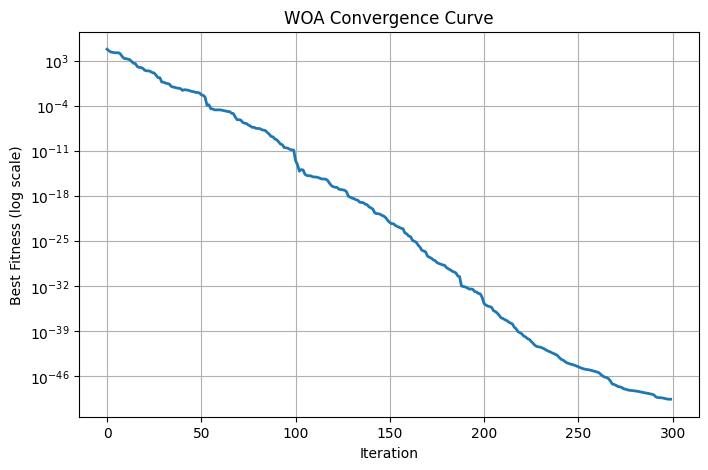

In [10]:
plt.figure(figsize=(8,5))
plt.plot(curve, linewidth=2)
plt.yscale('log')
plt.title('WOA Convergence Curve')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness (log scale)')
plt.grid(True)
plt.show()
